DATA AUGMENTATION: ESPANDERE L'ESPERIENZA VISIVA

Immagina di voler insegnare ad un bambino a riconoscere un cane, non gli mostrereste solo foto di un cane seduto difronte a lui, fareste vedere il cane in diversi casi, la data augmentation è il nostro modo di espandere l'esperienza visiva della rete neurale senza scattare effetivamente foto.
Come si creano nuovi mondi partendo da un unico scatto?

Geometria della Variazione
Creare nuovi mondi da un singolo scatto
Il successo di una CNN dipende dalla qualità e dalla quantità dei dati. Spesso però ottenere nuovi campioni reale è costoso o impossibile. La Data Augmentation risolve questo limite creando varianti artificiali coerenti.
Attraverso manipolazione geometriche che preservano l'etichetta dell'immagine, insegniamo alla rete che un oggetto rimane tale anche se visto da prospettive o orientamenti leggermente diversi. Insegnamo alla rete un convetto fondamentale, l'invarianza, un gatto è sempre un gatto sia che stia camminando verso destra sia che stia camminando verso sinistra.
Stiamo allenando la rete a ignorare il superfluo per concentrarsi sull'essenziale

Rotazioni e Flip
Invarianza all'orientamento spaziale.
- Rotazione casuale: applicare angoli di rotazione contenuti per simulare imperfezioni nell'inquadratura del soggetto. Simula l'imprecisione umane, raramente scattiamo foto perfette.
- Horizontal Flip: specchiare l'immagine lungo l'asse verticale, essenziale per oggetti con simmetria naturale come volti o veicoli. Se un modello impara a riconoscere un'auto che va verso sinistra, deve saperla riconoscere anche se va verso destra.
- Vertical Flip: operazione meno comune, utile in contesti specifici come l'imaging satellitare o la microscopia medica
- La trasformazione lineare di un pixel può essere descritta tramite una matrice di rotazione applicata alle coordinate spaziali.

Ma la geometria non finisce qui, dobbiamo anche gestire la distranza e la posizione.

Zoom e Traslazioni
Zoom e traslazioni servono a rompere la pigrizia della rete, se mostriamo oggetti sempre perfettamente centrati ed oggetti sempre della stessa dimensione, la rete impara a cercare le feature solo in quelle coordinate.
- Random Zoom: ingrandire o rimpicciolire il soggetto simula la variazione di distanza tra la camera e l'oggetto, forzando la rete a ignorare la scala assoluta.
- Widt and Height Shift: spostare l'immagine lungo gli assi X o Y assicura che il modello non impari che l'oggetto debba trovarsi sempre esattamente al centro del frame.
- Fill Mode: Quando trasformiamo un'immagine, creiamo dei pixel vuoti ai bordi. Tecniche come il 'nearest fill' o il 'wrap' decidono come riempire questi spazi artificiali.

Attenzione, non tutte le trasformazioni sono lecite, esiste un limite semantico.

Invarianza Semantica
L'importanza della coerenza delle etichette.
La regola d'oro dell'augmentation è che la trasformazione non deve cambiare la classse dell'oggetto. Se stiamo addestrando un modello a riconoscere i numeri e ruotando un '6' otteniamo un '9' (cambio etichetta), stiamo introducendo rumore dannoso.
Dobbiamo quindi scegliere le trasformazioni in base al dominio applicativo: un ribaltamento orizzontale va bene per un cane, ma potrebbe rovinare il riconoscimento del testo scritto.
Ribaltare un volto va bene, ma ribaltare una radiografica medica potrebbe invertire la posizione del cuore, portando a diagnosi errate.
Scegliere le trasformazioni è essenziale del lavoro dello sviluppatore di reti neurali.

Vediamo come fare la data augmentation in modo automatizzato

Automazione del Flusso
Implementazione nei framework moderni
Inserire manualmente queste trasformazioni sarebbe inefficiente. Sia Keras che PyTorch offrono strumenti per applicare l'augmentation 'on-the-fly' durante il caricamento dei batch,
Questo approccio 'online' permete di generare potenzialmente varianti infinite senza occupare spazio aggiuntivo sul disco fisso, poichè le immagini vengono trasformate direttamente in memoria RAM.
E' come se il dataset diventasse virtualmente infinto per occupando sempre lo stesso spazio di memoria di partenza.

Keras ImageDataGenerator
Pipeline Integrata per modelli sequenziali.
- Preprocessing: la classe 'ImageDataGenerator' permette di definire in un unico oggetto tutte le percentuali di variazione ammesse.
Legge la catella, applica le rotazioni, flip e tagli, consegna i batch pronti al modello.
- Flow methods: metodi come 'flow_from_directory' automatizzano il caricamenteo e l'augmentation basandosi sulla struttura delle cartelle
- Evoluzione: nelle versioni più recenti, Keras integra l'augmentation direttamente come layer del modello tramite tf.keras.layers.RandomRotation. Questo permette alla trasformazione di correre direttamente sulla GPU, rendendo tutto più veloce.
- L'augmentation agisce come una funzione di mappatura stocastica applicata a ogni batch durante la fase di addestramento.

PyTorch - Torchvision Transforms
- Composizione modulare: In PyTorch usiamo 'v2.Compose' per concatenare trasformazioni come 'Tolmage' 'RandomRotation' e 'Normalize' in una pipeline flessibile
- Trasformazioni stocastiche: una tecnica avanzata (TTA) prevede di fare previsioni su diverse versioni aumentate dell'immagine di test e mediarne i risultati per una predizione più accurata.
- GPU Acceleration: le nuove API di PyTorch permettono di eseguire l'augmentation direttamente sulla scheda video, eliminando il collo di bottiglia della CPU.

Ma quando conviene salvare le immagini, e quando generarle al volo?

Online vs Offline
Quando scegliere la pre-generazione
L'augmentation offline salva le varianti sul disco raddoppiando il dataset statisticamente. Si usa solo con dataset minuscoli dove l'overhead di calcolo 'on-the-fly' sarebbe sproporzionato. crei le varianti una volta per tutte e le salvi sul disco.
L'augmentation online è lo standard per il Deep Learning moderno: ogni volta che la rete vede un'immagine in un'epoca diversa, quella stessa immagine appare leggermente mutata. Non occupa spazio sul disco e garantisce la massima varietà possibile.
Nel 99% dei casi la via migliore è online

Ma quel'è l'impatto di tutto questo sulla nostra rete?

L'Impatto sulla Generalizzazione
Il vero nemoci del Deep Learning è la pigrizia cognitiva del modello che tende a 'memorizzare' i dati. L'augmentation rompe questa memorizzazione forzando la rete a estrarre solo le caratteristiche semantiche stabili.
La varietà sintetica aiuta il modello a comportarsi meglio sui dati mai visti, riducendo drasticamente il gap tra accuratezza di training e di validazione.
Rendendo i dati rumorosi e variabili, costringiamo la rete a cercare caratteristiche stabili e robuste. E' quindi una forma di regolarizzazione, come aggiungere pesi estra durante l'allenamento.
In che modo agisce sulla matematica dell'errore?

Combattere l'Overfitting
Aumentare il costo della memorizzazione
- Invarianza alle feature irrilevanti: la rete smette di dare importanza alla posizione esatta o all'illuminazione se queste cambiano continuamente
- Dataset virtualmente infinito: con l'augmentation corretta, la rete non vede quasi mai due volte lo stesso identico input numerico. Poichè la rete non vede quasi mai lo stesso input non può incastrarsi tra minimi locali che appartengono ad un singolo esempio.
- Smoothing della superficie di errore: la variabilità dei dati agisce come un rumore benefico che aiuta l'ottimizzatore a trovare minimi più piatti e robusti.
- L'augmentatione riduce la varianza del modello aumentando la dimensione effettiva del dataset di addestramento.

Ma come misuriamo se l'augmentation sta realmente funzionando?

Validazione e Test
- Regola d'oro: mai applicare l'augmentation al set di test o di validazione. Dobbiamo valutare il modello su dati reali e statici per avere una misura onesta delle sue prestazioni.
- Test-Time Augmentation: tuttavia esiste una tecnica avanzata (TTA) prevede di fare previsioni su diverse versioni aumentate dell'immagine di test e fate la media dei risultati per una predizione più accurata
- Monitoraggio delle curve: con l'augmentation l'errore di training scende più lentamente, ma la curva di validazione segue più da vicino quella di addestramento, indicando salute nel modello.

Esempio concreto

Analisi Comparativa
Esperimento con e senza Augmentation
Una rete addestrata solo su 100 immagini, l'errore di training andrà zero quasi subito (per memorizzazione), ma l'accuratezza di validazione resterà bassa, questo perchè soffre di overfitting immediato.
Aggiungendo l'augmentation la stessa rete riesce a raggiungere una precisione accettabile. La curva di training scende più lentamente, perchè il compito è diventato più difficile, ma la curva di validazione salirà molto più in alto.
Questo dimostra che l'augmentation non è solo un accessorio, ma un componente critico del disegn di qualsiasi architettura di Computer Vision moderna.


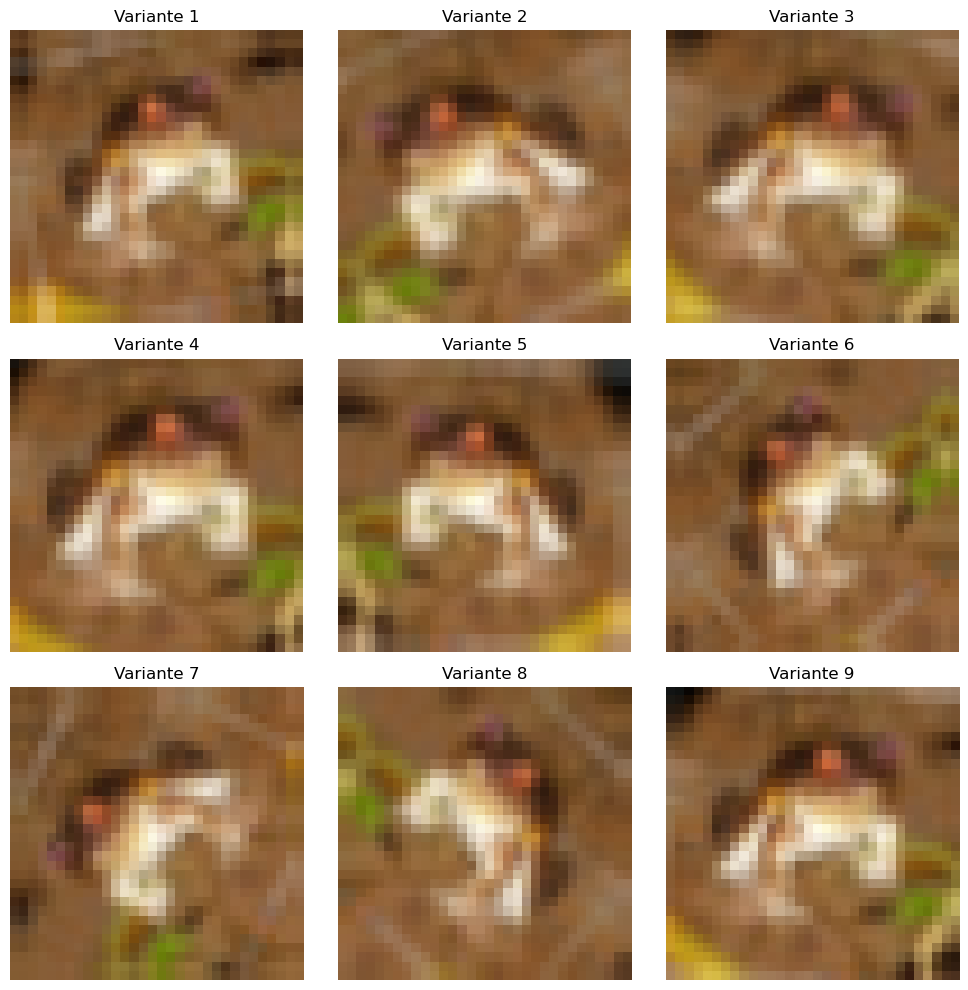

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# --- 1. DEFINIZIONE DELLA PIPELINE (Punto chiave 2) ---
# Creiamo un modello dedicato solo all'augmentation
data_augmentation = models.Sequential([
  layers.RandomFlip("horizontal"),        # Specchio orizzontale (Flip)
  layers.RandomRotation(0.2),             # Rotazione casuale (+/- 20%)
  layers.RandomZoom(0.1),                 # Zoom casuale (+/- 10%)
])

# --- 2. CARICAMENTO E PREPARAZIONE (Punto chiave 1) ---
# Usiamo CIFAR10 come base di test
(x_train, _), _ = tf.keras.datasets.cifar10.load_data()
image = x_train[0] # Prendiamo una singola immagine (es. un aereo)
image = np.expand_dims(image, 0) # Aggiungiamo la dimensione batch

# --- 3. VISUALIZZAZIONE (Punto chiave 3) ---
plt.figure(figsize=(10, 10))
for i in range(9):
    # Applichiamo l'augmentation sulla stessa immagine
    augmented_image = data_augmentation(image)
    
    plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_image[0].numpy().astype("uint8"))
    plt.axis("off")
    plt.title(f"Variante {i+1}")

plt.tight_layout()
plt.show()